In [1]:
# Import the FEMSystem Class from directory above
import sys
from VisualizeVF import VisualizeVF
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from Units2D import Units2D

In [2]:
from scipy.sparse.linalg import spsolve
from skfem import  ElementTriN1, ElementTriP1, Basis, BilinearForm, LinearForm, asm, condense, ElementVector
from skfem.helpers import curl, dot, div, grad
import numpy as np
from FEMSystem import FEMSystem
import jax.numpy as jnp
import pickle
from scipy.linalg import expm
from tqdm.auto import tqdm
from scipy.sparse import bmat

class RabiLondon2D:
    
    # Statics Solution
    femsystem:FEMSystem = None
    mesh = None
    u_left:jnp.ndarray = None
    u_right:jnp.ndarray = None
    u_even:jnp.ndarray = None
    u_odd:jnp.ndarray = None
    u_even_interior:jnp.ndarray = None
    u_odd_interior:jnp.ndarray = None
    theta_at_dofs:jnp.ndarray = None
    n:jnp.ndarray = None # Dimension of coefficients vector
    N:int = None # Total number of bosons
    coeffs:jnp.ndarray = None
    E_J:float = None
    E_C:float = None

    # Eigenvalues and Eigenvectors
    hamiltonian:jnp.ndarray = None
    eigenvectors:jnp.ndarray = None
    eigenvalues:jnp.ndarray = None
    charge_imbalance_eigenvalues:jnp.ndarray = None

    def __init__(self, pickled_obj):
        # Get Modes, Coefficients, and EJ/EC, and n/N + FEMSystem
        femsystem:FEMSystem = pickled_obj["femsystem"]
        femsystem.saveFigsDir = None # Turn OFF saving plots
        self.femsystem = femsystem
        self.mesh = femsystem.mesh
        self.u_even,self.u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]
        self.u_left,self.u_right = 1/jnp.sqrt(2)*(self.u_even - self.u_odd), 1/jnp.sqrt(2)* (self.u_even + self.u_odd)
        self.u_even_interior,self.u_odd_interior = self.u_even[femsystem.interior_dofs],self.u_odd[femsystem.interior_dofs]
        self.n,self.N,self.coeffs = pickled_obj["n"],pickled_obj["parameters"]["N"],pickled_obj["coeffs"]
        self.E_J,self.E_C = pickled_obj["E_J"],pickled_obj["E_C"]
        self.integrated_area = pickled_obj["integrated_area"]
        self.area = pickled_obj["parameters"]["sidelenX"] * pickled_obj["parameters"]["sidelenY"] * 2

        print(f"---- Successfully initialed RabiLondon2D Object ----")
        print(f"Integrated Area: {self.integrated_area} | Area: {self.area} | Error: {abs(self.integrated_area - self.area)/self.integrated_area*100:.2f}%")
        print(f"EJ: {self.E_J} | EC: {self.E_C} | EJ/EC: {self.E_J/self.E_C}")

        # Now run eigensolver
        self.hamiltonian, self.eigenvectors, self.eigenvalues, self.charge_imbalance_eigenvalues = self.eigensolver()


        # Keep scalar as plain float for downstream scipy/skfem assembly code.
        self.omega_q = float(self.eigenvalues[1] - self.eigenvalues[0])
        print(f"Qubit Frequency: {self.omega_q} (non-dimensional energy units)")



    # Assume that half charge imbalance is perfectly centered around 0
    # So odd n: -1 0 1 in middle, even n: -0.5 0.5 in middle
    def eigensolver(self):
        # Construct charge imbalance Eigenvalues
        charge_imbalance_eigenvalues = (self.n-1)/2 - jnp.arange(self.n)

        # Construct Discrete Hamiltonian Matrix
        def Jz2(n):
            j = (n-1)/2
            diagonals = j - jnp.arange(n)
            return jnp.diag(diagonals**2)
        def off_diag(n,k):
            ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
            super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
            result = super_diag_matrix + sub_diag_matrix
            return result 
        def cos_phi(n):
            return off_diag(n,1) / 2
        hamiltonian = self.E_C * Jz2(self.n) - self.E_J * cos_phi(self.n) # No need for e_0 term, since we are only interested in eigenvectors

        # Find Eigenvalues and Eigenvectors
        eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

        # Normalize eigenvectors
        eigenvectors = eigenvectors / jnp.sqrt(jnp.sum(jnp.abs(eigenvectors)**2, axis=0, keepdims=True))
        return hamiltonian, eigenvectors, eigenvalues, charge_imbalance_eigenvalues


    def helmholtz_solver(self,omega_d,c_bar,kappa,source_obj,epsilon=1e-4,use_coulomb_gauge=True):
        # Coerce potential JAX scalars into plain floats before skfem/scipy usage.
        omega_d = float(omega_d)
        c_bar = float(c_bar)
        kappa = float(kappa)
        source_coord = source_obj["source_coord"]
        sigma = float(source_obj["sigma"])
        m = float(source_obj["m"])


        # Define Coefficients
        a_coeff = - (omega_d/c_bar)**2
        b_coeff = 1/(kappa**2) * float(self.area) / float(self.N)

        # Define Nedelic Basis
        nedelic_element = ElementTriN1()
        basis_edge = Basis(self.mesh, nedelic_element, intorder=self.femsystem.intorder)

        # Approximated Time-Indendent Charge Density, in Nodal Basis
        psi_exp = (self.u_left **2 + self.u_right**2) * self.N / 2 + epsilon

        # Define Bilinear Form
        @BilinearForm
        def bilinear_form(u,v,w):
            second_term_coeff = a_coeff + b_coeff * w['psi_exp']
            return curl(u) * curl(v) + second_term_coeff * dot(u, v)

        # Define Linear Form, the Divergence-Free Dipole Source
        @LinearForm
        def dipole_source(v, w):
            x = w.x[0]
            y = w.x[1]
            x0, y0 = source_coord
            M = (m / (np.pi * sigma**2)) * np.exp(-((x - x0)**2 + (y - y0)**2) / sigma**2)
            Jx = -M * 2 * (y - y0) / sigma**2
            Jy =  M * 2 * (x - x0) / sigma**2
            J_vec = np.array([Jx, Jy])
            return dot(J_vec, v)

        # Assemble Matrices
        A_matrix = asm(bilinear_form, basis_edge,
                    psi_exp=self.femsystem.basis.interpolate(np.asarray(psi_exp, dtype=np.float64)))      
        b_vector = asm(dipole_source, basis_edge)

        if not use_coulomb_gauge:
            A_sol = np.zeros(basis_edge.N)
            D = basis_edge.get_dofs().all()
            A_int, b_int, x_int, I = condense(A_matrix, b_vector, D=D)

            # Solve 
            A_sol[I] = spsolve(A_int, b_int)
            return A_sol, basis_edge
        else:

            # Baiscally adds another basis to add Lagrange multiplier to weak form. 
            # Essentially another degree of freedom to solver for, in a large matrix. 
            basis_lam = Basis(self.mesh, ElementTriP1(), intorder=self.femsystem.intorder)

            @BilinearForm
            def G_form(lam, v, w):
                # weak gauge constraint block
                return dot(v, grad(lam))
            
            Gmat = asm(G_form, basis_lam, basis_edge).T
            DA = np.asarray(basis_edge.get_dofs().all(), dtype=np.int64)
            IA = np.setdiff1d(np.arange(basis_edge.N), DA)
            A_int = A_matrix[IA][:,IA]
            b_int = b_vector[IA]
            G_int = Gmat[:,IA]

            lam_keep = np.arange(1, basis_lam.N)
            Gir = G_int[lam_keep, :]
            S = bmat([[A_int, Gir.T],
                [Gir, None]], format='csr')
            rhs = np.concatenate([b_int, np.zeros(lam_keep.size)])
            sol = spsolve(S, rhs)
            A_i = sol[:IA.size]
            A_sol = np.zeros(basis_edge.N)
            A_sol[IA] = A_i


            # Verify
            lam = sol[IA.size:]
            rA = np.linalg.norm(A_int @ A_i + Gir.T @ lam - b_int)
            rG = np.linalg.norm(Gir @ A_i)
            print("saddle residual A:", rA, "gauge residual:", rG)

            return A_sol, basis_edge
    
    def _project_to_coulomb_gauge_p1(self, femsystem, basis_edge, A_sol: np.ndarray):
        """Project edge A to vector-P1 and remove gradient component.

        This computes A_df = A - grad(phi), where phi solves
            Delta(phi) = div(A)
        with homogeneous Dirichlet boundary conditions.

        Returns
        -------
        A_df_coeffs : np.ndarray
            Vector-P1 coefficients of the cleaned field.
        basis_vec_p1 : Basis
            Vector-P1 basis associated with A_df_coeffs.
        """
        nodal_element = femsystem.element
        basis_p1 = Basis(self.mesh, nodal_element, intorder=femsystem.intorder)
        basis_vec_p1 = Basis(self.mesh, ElementVector(nodal_element), intorder=femsystem.intorder)

        @BilinearForm
        def mass_scalar(u, v, w):
            return u * v

        @BilinearForm
        def mass_vec(u, v, w):
            return dot(u, v)

        @BilinearForm
        def stiffness_scalar(u, v, w):
            return dot(grad(u), grad(v))

        @LinearForm
        def rhs_proj_A(v, w):
            return dot(w["A_edge"], v)

        @LinearForm
        def rhs_divA(v, w):
            return div(w["A_vec"]) * v

        @LinearForm
        def rhs_gradphi(v, w):
            return dot(grad(w["phi"]), v)

        A_edge_disc = basis_edge.interpolate(np.asarray(A_sol, dtype=np.float64))
        M_vec = asm(mass_vec, basis_vec_p1)

        # Step 1: L2 project edge field -> vector-P1
        rhs_A = asm(rhs_proj_A, basis_vec_p1, A_edge=A_edge_disc)
        A_vec_coeff = spsolve(M_vec, rhs_A)
        A_vec_disc = basis_vec_p1.interpolate(A_vec_coeff)

        # Step 2: solve Delta phi = div(A) with homogeneous Dirichlet BC
        M_s = asm(mass_scalar, basis_p1)
        rhs_div = asm(rhs_divA, basis_p1, A_vec=A_vec_disc)
        divA_nodes = spsolve(M_s, rhs_div)

        K_s = asm(stiffness_scalar, basis_p1)
        phi = np.zeros(basis_p1.N)
        D = basis_p1.get_dofs().all()
        K_int, f_int, x_int, I = condense(K_s, divA_nodes, D=D)
        phi[I] = spsolve(K_int, f_int)

        # Step 3: A_df = A - grad(phi)
        rhs_grad = asm(rhs_gradphi, basis_vec_p1, phi=basis_p1.interpolate(phi))
        gradphi_coeff = spsolve(M_vec, rhs_grad)
        A_df_coeff = A_vec_coeff - gradphi_coeff

        return A_df_coeff, basis_vec_p1

    def divergence_report(self, basis_edge, A_sol):
        """Return L2-like RMS of div(A) before/after div-free cleanup on vector-P1."""
        # Raw projection
        _, _, div_raw, _ = self._project_nedelec_to_vector_p1(
            self.femsystem, basis_edge, A_sol, enforce_divfree=False
        )
        # Cleaned projection
        _, _, div_clean, _ = self._project_nedelec_to_vector_p1(
            self.femsystem, basis_edge, A_sol, enforce_divfree=True
        )

        div_raw_np = np.asarray(div_raw, dtype=np.float64)
        div_clean_np = np.asarray(div_clean, dtype=np.float64)
        raw_rms = float(np.sqrt(np.mean(div_raw_np**2)))
        clean_rms = float(np.sqrt(np.mean(div_clean_np**2)))
        ratio = clean_rms / raw_rms if raw_rms > 0 else np.nan
        return {
            "div_rms_raw": raw_rms,
            "div_rms_clean": clean_rms,
            "clean_over_raw": ratio,
        }

    def _project_nedelec_to_vector_p1(self, femsystem, basis_edge, A_sol: np.ndarray, enforce_divfree: bool = False):
        """L² project Nédélec A onto vector P1.

        If enforce_divfree=True, apply a Coulomb-gauge cleanup A <- A - grad(phi)
        before extracting Ax, Ay, divA, and |A|^2.
        """
        if enforce_divfree:
            coeffs, basis_vec_p1 = self._project_to_coulomb_gauge_p1(femsystem, basis_edge, A_sol)
            A_p1_disc = basis_vec_p1.interpolate(coeffs)
        else:
            nodal_element = femsystem.element
            basis_vec_p1 = Basis(
                self.mesh, ElementVector(nodal_element), intorder=femsystem.intorder
            )

            @BilinearForm
            def mass_vec(u, v, w):
                return dot(u, v)

            @LinearForm
            def rhs_proj(v, w):
                return dot(w["A"], v)

            A_disc = basis_edge.interpolate(np.asarray(A_sol, dtype=np.float64))
            M = asm(mass_vec, basis_vec_p1)
            rhs = asm(rhs_proj, basis_vec_p1, A=A_disc)
            coeffs = spsolve(M, rhs)
            A_p1_disc = basis_vec_p1.interpolate(coeffs)

        val = np.asarray(A_p1_disc.value)
        Ax = jnp.asarray(val[0])
        Ay = jnp.asarray(val[1])
        divA = jnp.asarray(div(A_p1_disc))
        a2 = Ax * Ax + Ay * Ay
        return Ax, Ay, divA, a2

    def _epsilon_four_terms(self,femsystem,basis_edge,A_sol,phi_i,phi_j):
        def T_nabla2(u1, g1, u2, g2, x):

            del u1, u2, x
            return -jnp.sum(jnp.conj(g1) * g2, axis=0)

        Ax, Ay, divA, a2 = self._project_nedelec_to_vector_p1(femsystem, basis_edge, A_sol)

        def T_divA(u1, g1, u2, g2, x):
            del g1, g2, x
            return 1j*jnp.conj(u1) * divA * u2

        def T_Adot_grad(u1, g1, u2, g2, x):
            del g1, x
            adot = Ax * g2[0] + Ay * g2[1]
            return 1j*jnp.conj(u1) * adot

        def T_A2(u1, g1, u2, g2, x):
            del g1, g2, x
            return jnp.conj(u1) * a2 * u2

        laplacian_term = femsystem.integrate_two(T_nabla2, phi_i, phi_j)
        first_cross_term = femsystem.integrate_two(T_divA, phi_i, phi_j)
        second_cross_term = femsystem.integrate_two(T_Adot_grad, phi_i, phi_j)
        a2_term = femsystem.integrate_two(T_A2, phi_i, phi_j)

        return laplacian_term, first_cross_term, second_cross_term, a2_term
    
    def get_corrections(self,basis_edge,A_sol,u1,u2,omega_d):
        laplacian_term, first_cross_term, second_cross_term, a2_term = self._epsilon_four_terms(
            self.femsystem, basis_edge, A_sol, u1, u2
        )

        A1_coeff = (first_cross_term+second_cross_term)
        A2_coeff = a2_term / 2

        def correction_func(t):
            s = jnp.sin(omega_d*t)
            res = A1_coeff * s + A2_coeff*2 * (s**2) # the integral is multiplied by s**2, which is 2A_2, defined in doc. 
            return res

        return correction_func, A1_coeff, A2_coeff

    def _charge_imbalance_eigenvalues(self):
        # Even / Odd difference
        m_values = self.charge_imbalance_eigenvalues
        n_left_values  = (self.N / 2) - m_values
        n_right_values = (self.N / 2) + m_values
        return m_values, n_left_values, n_right_values

    def _left_lowering_operator(self):
        # b_L |m> = sqrt(N_L(m)) |m + 1/2>  -> in this indexed basis: i -> i+1
        _, n_left_values, _ = self._charge_imbalance_eigenvalues()
        mat = jnp.zeros((self.n, self.n))
        for i in range(0, self.n - 1):
            mat = mat.at[i + 1, i].set(jnp.sqrt(n_left_values[i]))
        return mat

    def _left_raising_operator(self):
        return self._left_lowering_operator().T

    def _right_lowering_operator(self):
        # b_R |m> = sqrt(N_R(m)) |m - 1/2>  -> in this indexed basis: i -> i-1
        _, _, n_right_values = self._charge_imbalance_eigenvalues()
        mat = jnp.zeros((self.n, self.n))
        for i in range(1, self.n):
            mat = mat.at[i - 1, i].set(jnp.sqrt(n_right_values[i]))
        return mat

    def _right_raising_operator(self):
        return self._right_lowering_operator().T

    def _total_left_operator(self):
        """
        Returns the total left operator matrix (n x n diagonal) for left particle number in the middle n states.
        """
        m_values, n_left_values, n_right_values = self._charge_imbalance_eigenvalues()
        return jnp.diag(n_left_values)

    def _total_right_operator(self):
        """
        Returns the total right operator matrix (n x n diagonal) for right particle number in the middle n states.
        """
        m_values, n_left_values, n_right_values = self._charge_imbalance_eigenvalues()
        return jnp.diag(n_right_values)
    
    def rabi_hamiltonian(self,basis_edge,A_sol,omega_d):
        # Compute the total time evolution matrix:
        left_raising = self._left_raising_operator()
        left_lowering = self._left_lowering_operator()
        right_raising = self._right_raising_operator()
        right_lowering = self._right_lowering_operator()

        raisings = [left_raising,right_raising] # Daggers
        lowerings = [left_lowering,right_lowering] # Regular b operators
        modes = [self.u_left,self.u_right]

        # Precompute epsilon functions for all (i, j) and store in a 2x2 array
        epsilon_funcs = [[self.get_corrections(basis_edge, A_sol, modes[i], modes[j], omega_d) for j in range(2)] for i in range(2)]
        # Precompute raising@lowering matrices for all (i, j)
        raising_lowering_mats = [[raisings[i] @ lowerings[j] for j in range(2)] for i in range(2)]

        def res(t):
            mat = self.hamiltonian

            # Corrections
            for i in range(2):
                for j in range(2):
                    epsilon_val = epsilon_funcs[i][j][0](t) # The first index is the actual correction function. 
                    curr_mat = raising_lowering_mats[i][j]
                    mat += epsilon_val * curr_mat
            mat = 0.5 * (mat + jnp.conj(mat.T))
            return mat
    

        # Get matrix decomposition:
        A1_mat = jnp.zeros((self.n, self.n), dtype=jnp.complex64)
        A2_mat = jnp.zeros((self.n, self.n), dtype=jnp.complex64)
        for i in range(2):
            for j in range(2):
                A1_mat += epsilon_funcs[i][j][1] * raising_lowering_mats[i][j]
                A2_mat += epsilon_funcs[i][j][2] * raising_lowering_mats[i][j]
        
        return res, A1_mat, A2_mat

    def correction_matrix(self,basis_edge,A_sol,omega_d):
        rabi_hamiltonian = self.rabi_hamiltonian(basis_edge,A_sol,omega_d)
        def res(t):
            return rabi_hamiltonian(t) - self.hamiltonian
        return res        
    
    # # Computes matrix element for omega_d and 2omega_d states. Basically the <c1|H_M(only omega_d)|c2>
    # def matrix_el(self,c1,c2):

    def TLS_matrix(self,matrix):
        ground_state = self.eigenvectors[:,0]
        excited_state = self.eigenvectors[:,1]
        
        # 2x2 matrix may be complex due to A-driven corrections.
        mat = jnp.zeros((2,2), dtype=jnp.complex64)
        mat = mat.at[0,0].set(jnp.vdot(ground_state,matrix @ ground_state))
        mat = mat.at[0,1].set(jnp.vdot(ground_state,matrix @ excited_state))
        mat = mat.at[1,0].set(jnp.vdot(excited_state,matrix @ ground_state))
        mat = mat.at[1,1].set(jnp.vdot(excited_state,matrix @ excited_state))
        return mat
    
    def pauli_decompose(self,mat):
        # Force complex dtype so sigma_y can be represented even if input is real.
        mat_c = jnp.asarray(mat, dtype=jnp.complex64)
        I = jnp.array([[1, 0], [0, 1]], dtype=mat_c.dtype)
        sx = jnp.array([[0, 1], [1, 0]], dtype=mat_c.dtype)
        sy = jnp.array([[0, -1j], [1j, 0]], dtype=mat_c.dtype)
        sz = jnp.array([[1, 0], [0, -1]], dtype=mat_c.dtype)
        # Calculate coefficients
        c0 = 0.5 * jnp.trace(mat_c @ I)
        c1 = 0.5 * jnp.trace(mat_c @ sx)
        c2 = 0.5 * jnp.trace(mat_c @ sy)
        c3 = 0.5 * jnp.trace(mat_c @ sz)
        # Stack to a vector
        return jnp.array([c0, c1, c2, c3], dtype=mat_c.dtype)
        
    
    def evolve_piecewise_progress(self,c0, t_grid, H_of_t, schrodinger=True):
        c = np.asarray(c0, dtype=np.complex128)
        if schrodinger:
            c = c / np.linalg.norm(c)

        out = np.zeros((len(t_grid), len(c0)), dtype=np.complex128)
        out[0] = c

        for k in tqdm(range(len(t_grid)-1), desc="Time evolution"):
            dt = t_grid[k+1] - t_grid[k]
            tm = 0.5 * (t_grid[k] + t_grid[k+1])
            Hm = np.asarray(H_of_t(tm), dtype=np.complex128)
            A = (-1j * dt) * Hm if schrodinger else (dt * Hm)
            U = expm(A)
            c = U @ c
            if schrodinger:
                c = c / np.linalg.norm(c)
            out[k+1] = c
        return out

    def check_hermiticity_and_norm(self,H, t_grid, output, atol_H=1e-10, atol_norm=1e-10):
        # --- Hermiticity check ---
        herm_abs_err = []
        herm_rel_err = []

        for t in t_grid:
            Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
            anti = Ht - Ht.conj().T
            abs_err = np.linalg.norm(anti, ord='fro')
            denom = max(np.linalg.norm(Ht, ord='fro'), 1e-30)
            rel_err = abs_err / denom
            herm_abs_err.append(abs_err)
            herm_rel_err.append(rel_err)

        herm_abs_err = np.array(herm_abs_err)
        herm_rel_err = np.array(herm_rel_err)

        # --- Normalization check ---
        C = np.asarray(output, dtype=np.complex128)
        probs = np.sum(np.abs(C)**2, axis=1)        # should be 1 for each time
        norm_err = np.abs(probs - 1.0)

        # --- NaN/Inf checks ---
        has_bad_H = False
        for t in t_grid:
            Ht = np.asarray(H(t) if callable(H) else H, dtype=np.complex128)
            if not np.all(np.isfinite(Ht)):
                has_bad_H = True
                break
        has_bad_output = not np.all(np.isfinite(C))

        # --- Report ---
        print("Hermiticity:")
        print(f"  max ||H-H†||_F              = {herm_abs_err.max():.3e}")
        print(f"  max relative hermiticity err = {herm_rel_err.max():.3e}")
        print(f"  all times Hermitian (abs<{atol_H})? {np.all(herm_abs_err < atol_H)}")

        print("\nNormalization of output:")
        print(f"  min sum|c|^2 = {probs.min():.15f}")
        print(f"  max sum|c|^2 = {probs.max():.15f}")
        print(f"  max |sum|c|^2 - 1| = {norm_err.max():.3e}")
        print(f"  all times normalized (err<{atol_norm})? {np.all(norm_err < atol_norm)}")

        print("\nFinite-value checks:")
        print(f"  H contains only finite values? {not has_bad_H}")
        print(f"  output contains only finite values? {not has_bad_output}")

        # Optional: return indices where checks fail
        bad_H_idx = np.where(herm_abs_err >= atol_H)[0]
        bad_norm_idx = np.where(norm_err >= atol_norm)[0]
        return {
            "herm_abs_err": herm_abs_err,
            "herm_rel_err": herm_rel_err,
            "probs": probs,
            "norm_err": norm_err,
            "bad_H_idx": bad_H_idx,
            "bad_norm_idx": bad_norm_idx,
        }

## Parameters that worked:

source: (5.0,30.0) 
sigma: 10  
m: 100 
drive: half of qubit frequency   
everything else: set by \xi = .39A

In [32]:
pickled_obj = {}
pickled_obj = {}
with open('./../2D/allplots/square10sep20num100/results.pkl', 'rb') as f:
# with open('./../2D/allplots/square20sep20num100/results.pkl', 'rb') as f:
    pickled_obj = pickle.load(f)
rabilondon = RabiLondon2D(pickled_obj)
print(pickled_obj["parameters"])

# Now define all physical and material parameters. Only need \xi and desired kapp
xi = .39e-10 * 1
kappa = 1
units2d = Units2D(xi,kappa)
# Check units, if transition frequency in nondim units is 4, then must equal plasma frequency
kappa_computed,c_bar = units2d.kappa_cbar_from_xi(xi)
print(f"Computed kappa: {kappa_computed}, c_bar: {c_bar}")
plasma_freq1,plasma_freq2 = c_bar/kappa, units2d.convert_energy_to_rad_s(4,xi)
print("\n\n")
print(f"Using xi = {xi*1e10} A")
print(f"Units check: Plasma frequencies must be equal (in rad/s): {plasma_freq1} | {plasma_freq2}")
print(f"kappa: {kappa}, c_bar: {c_bar}")

n_s  = units2d.n_sfromxi(xi)
print(f"n_s = {n_s} | n_s xi^3: {n_s*xi**3}")
deltaZ = units2d.compute_dz(n_s,rabilondon.N,rabilondon.area)
print(f"deltaZ: {deltaZ}")


# London penetration depth from n_s
lambda_L = units2d.london_from_n_s(n_s)
print(f"lambda_L: {lambda_L}")

---- Successfully initialed RabiLondon2D Object ----
Integrated Area: 211.7740478515625 | Area: 200.0 | Error: 5.56%
EJ: 2.3853302001953125 | EC: 1.0312327146530151 | EJ/EC: 2.3130862712860107
Qubit Frequency: 1.8735647201538086 (non-dimensional energy units)
{'N': 100, 'separation': 20.0, 'sidelenX': 10.0, 'sidelenY': 10.0, 'padding': 20.0, 'gridlenX': 80.0, 'gridlenY': 50.0, 'lc_large': 5.0, 'lc_small': 1.0}
Effective mass: 4.5098370293394736e-33 kg | 0.0024779324337030075 times (2m_e)
Computed kappa: 1.0000000000000002, c_bar: 7.686986102564269e+18



Using xi = 0.39 A
Units check: Plasma frequencies must be equal (in rad/s): 7.686986102564269e+18 | 7.686986102564269e+18
kappa: 1, c_bar: 7.686986102564269e+18
n_s = 2.2984589675009035e+31 | n_s xi^3: 1.363422874931861
deltaZ: 0.3667240803958113
lambda_L: 3.900000000000001e-11


0.46839118003845215
Qubit Frequency (in nondim units): 1.8735647201538086 | (in rad/s):3.60051649151926e+18
Expected effective london penetration depth: 1.1318347600173548
saddle residual A: 1.6284699295685416e-15 gauge residual: 1.7045213908256136e-15


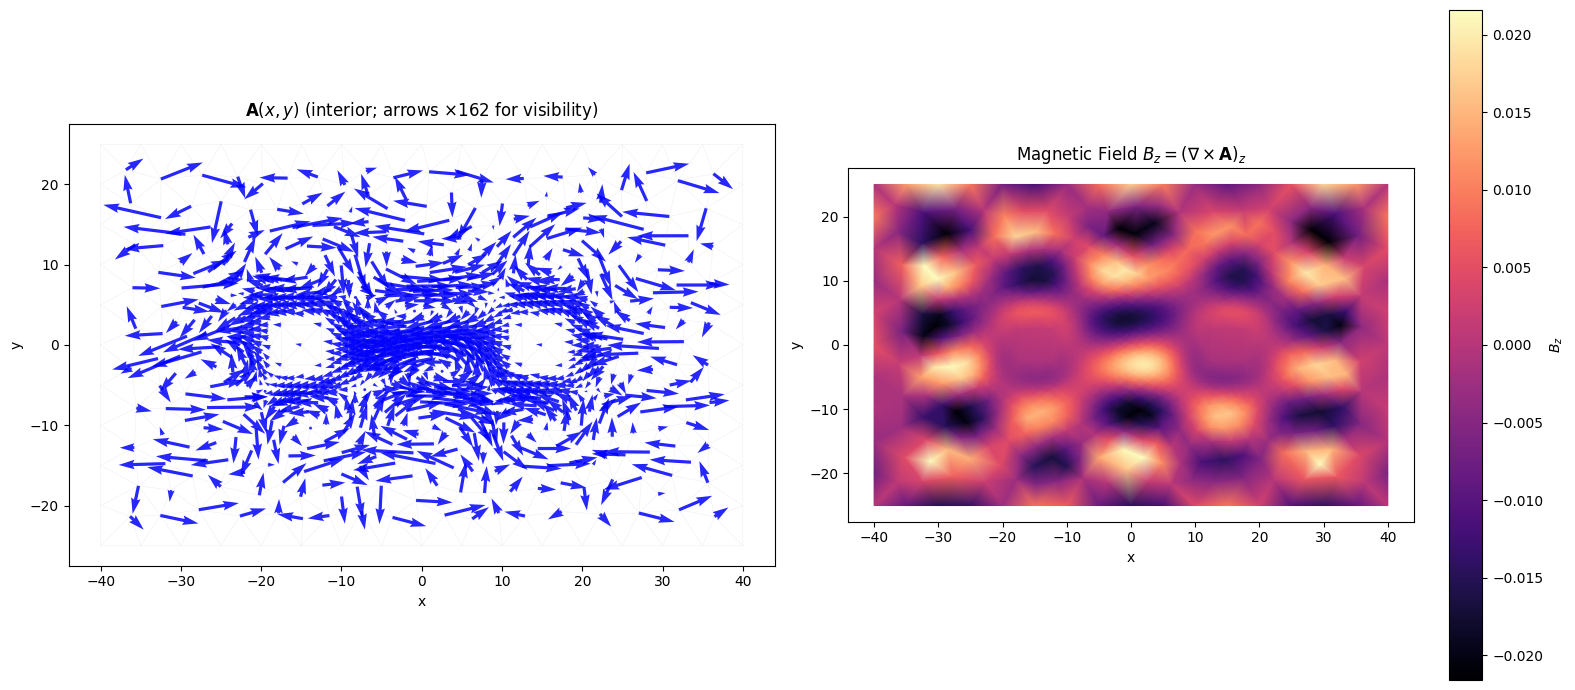

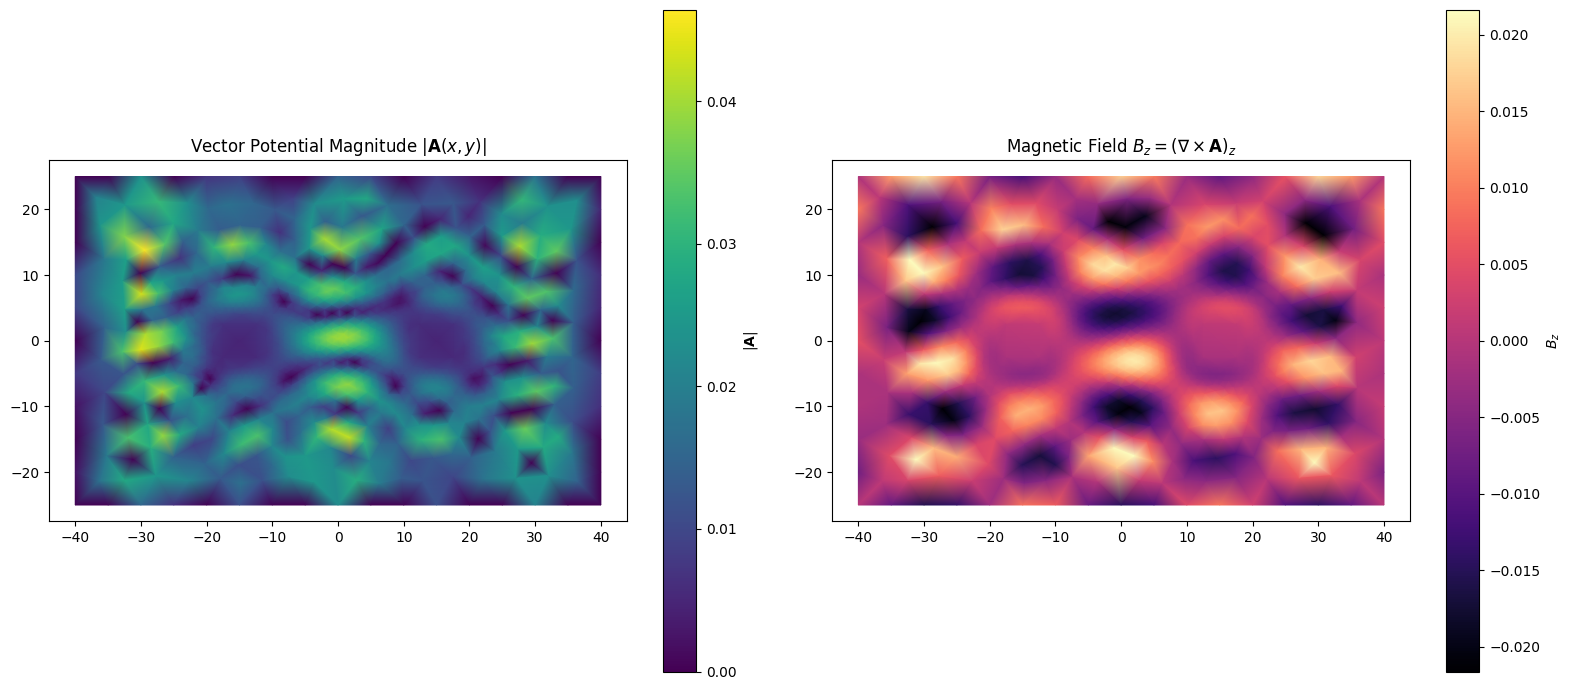

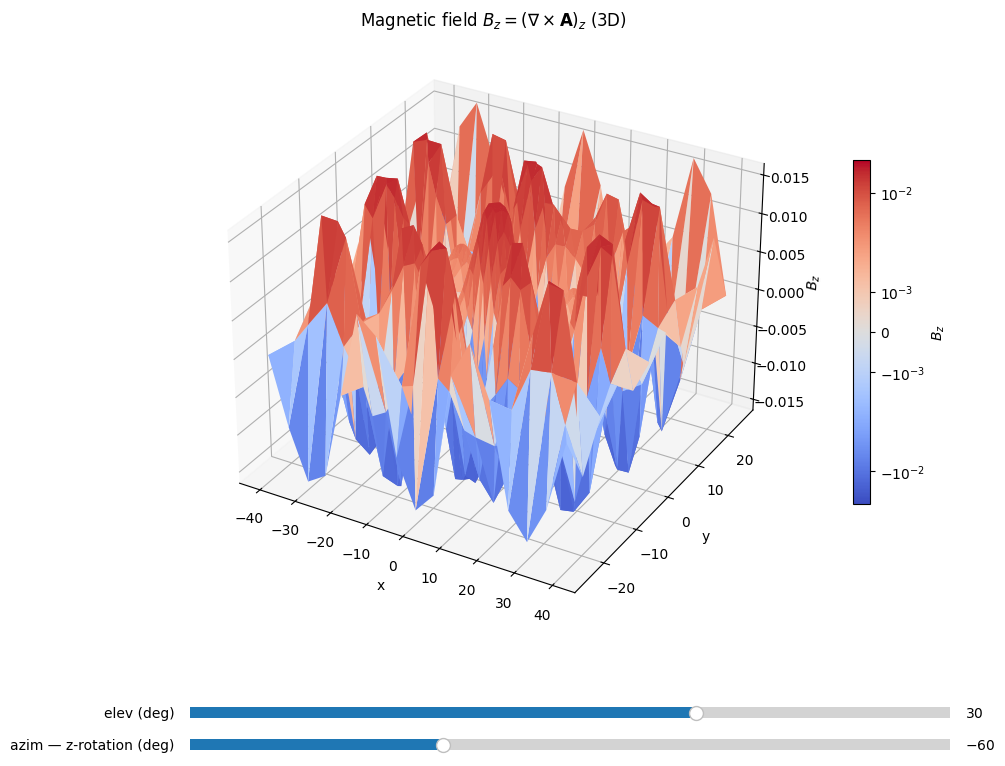

(<Figure size 1000x800 with 4 Axes>,
 <Axes3D: title={'center': 'Magnetic field $B_z = (\\nabla \\times \\mathbf{A})_z$ (3D)'}, xlabel='x', ylabel='y', zlabel='$B_z$'>)

In [71]:
# Define all Parameters
omega_d_nondim = rabilondon.omega_q # on resonance drive
omega_d_rad_s = units2d.convert_energy_to_rad_s(omega_d_nondim,xi)   #convert to rad/s
print(omega_d_rad_s/c_bar)
print(f"Qubit Frequency (in nondim units): {omega_d_nondim} | (in rad/s):{omega_d_rad_s}")

# Compute expected effective london penetration depth
wavevec_mag = np.sqrt(1/kappa**2-omega_d_rad_s**2/c_bar**2)
lambda_eff = 1/wavevec_mag
print(f"Expected effective london penetration depth: {lambda_eff}")

source_coord = (5,30.0)
sigma = 10
m = 10 # Magnitude of drive.
source_obj = {
    "source_coord": source_coord,
    "sigma": sigma,
    "m": m
}

# Run Solver
A_sol, basis_edge = rabilondon.helmholtz_solver(omega_d_rad_s,c_bar,kappa,source_obj)

# Visualize Solution
vis = VisualizeVF(rabilondon.mesh, basis_edge, A_sol)
fig, ax = vis.visualize_vf(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_vf_mag(A_sol, bz_symmetric_percentile=99.0)
vis.visualize_bz_surface(A_sol, bz_symmetric_percentile=99.0)

# Construct Rabi Hamiltonian

In [72]:
H_of_t, A1_mat, A2_mat = rabilondon.rabi_hamiltonian(basis_edge,A_sol,omega_d_nondim)

# Get 2 x 2 Matrices for TLS
A1_mat_TLS = rabilondon.TLS_matrix(A1_mat)
A2_mat_TLS = rabilondon.TLS_matrix(A2_mat)
print(f"A1_mat_TLS: {A1_mat_TLS}")
print(f"A2_mat_TLS: {A2_mat_TLS}")

# Get Pauli Decomposition
A1_mat_TLS_decomposed = rabilondon.pauli_decompose(A1_mat_TLS)
A2_mat_TLS_decomposed = rabilondon.pauli_decompose(A2_mat_TLS)
print(f"Order is identity, sigma_x, sigma_y, sigma_z")
print(f"A_1 Decomposed: {A1_mat_TLS_decomposed}")
print(f"A_2 Decomposed: {A2_mat_TLS_decomposed}")
rabi_freq = np.sqrt(A1_mat_TLS_decomposed[1]**2 + A1_mat_TLS_decomposed[2]**2)  
print(f"Approx Rabi Frequency (Assuming x and y components of A2 are trivial): {rabi_freq}")

A1_mat_TLS: [[0.+5.7131281e-05j 0.+5.7112414e-04j]
 [0.-5.7178555e-04j 0.+7.2804294e-05j]]
A2_mat_TLS: [[ 3.8100570e-03+0.j -1.7408664e-06+0.j]
 [-1.7409407e-06+0.j  3.7301208e-03+0.j]]
Order is identity, sigma_x, sigma_y, sigma_z
A_1 Decomposed: [ 0.        +6.4967790e-05j  0.        -3.3070683e-07j
 -0.00057145+0.0000000e+00j  0.        -7.8365065e-06j]
A_2 Decomposed: [ 3.7700888e-03+0.0000000e+00j -1.7409036e-06+0.0000000e+00j
  0.0000000e+00+3.7118753e-11j  3.9968058e-05+0.0000000e+00j]
Approx Rabi Frequency (Assuming x and y components of A2 are trivial): (0.0005714547587558627-0j)


In [84]:
# Eigenvectors are stored as columns; [:, 0] is the ground-state vector.
c0 = rabilondon.eigenvectors[:, 0]
t_grid = np.linspace(0, 20000, 100001)   # dt = 0.1
output = rabilondon.evolve_piecewise_progress(c0, t_grid, H_of_t)
rabilondon.check_hermiticity_and_norm(H_of_t, t_grid, output)

Time evolution:   0%|          | 0/100000 [00:00<?, ?it/s]

Hermiticity:
  max ||H-H†||_F              = 0.000e+00
  max relative hermiticity err = 0.000e+00
  all times Hermitian (abs<1e-10)? True

Normalization of output:
  min sum|c|^2 = 0.999999999999999
  max sum|c|^2 = 1.000000000000001
  max |sum|c|^2 - 1| = 8.882e-16
  all times normalized (err<1e-10)? True

Finite-value checks:
  H contains only finite values? True
  output contains only finite values? True


{'herm_abs_err': array([0., 0., 0., ..., 0., 0., 0.]),
 'herm_rel_err': array([0., 0., 0., ..., 0., 0., 0.]),
 'probs': array([1., 1., 1., ..., 1., 1., 1.]),
 'norm_err': array([1.11022302e-16, 0.00000000e+00, 2.22044605e-16, ...,
        2.22044605e-16, 0.00000000e+00, 2.22044605e-16]),
 'bad_H_idx': array([], dtype=int64),
 'bad_norm_idx': array([], dtype=int64)}

Fitted omega: 0.000574194087
Omega std err: 2.83e-08
RMSE: 0.0122


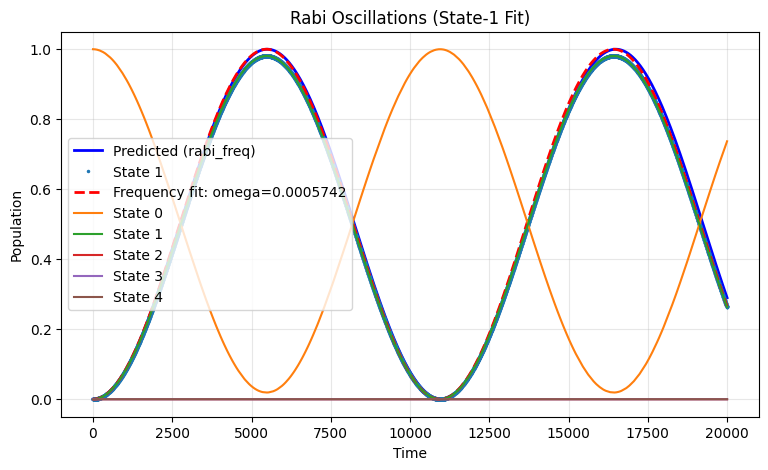

1.8735647
3.7294683
max |sum_all - 1| = 8.881784197001252e-16
min/max sum_all    = 0.9999999999999993 1.0000000000000009
min/max sum_0_1_2  = 0.0 1.0576695260236128e-82


In [85]:
# Rabi Oscillations plot + fit state-1 population to (1 - cos(omega * t))/2
from scipy.optimize import curve_fit

skip = 10

number_of_states = 5
eigenvalues, eigenvectors = rabilondon.eigenvalues, rabilondon.eigenvectors
populations = [[] for _ in range(number_of_states)]
for i in range(0, len(output), skip):
    psi = output[i]
    psi /= jnp.linalg.norm(psi)

    for j in range(number_of_states):
        p_j = jnp.abs(jnp.vdot(eigenvectors[:, j], psi))**2
        populations[j].append(p_j)

# Convert to arrays for fitting
sample_t = np.asarray(t_grid[::skip], dtype=float)
state1_pop = np.asarray(populations[1], dtype=float)


# Model requested: (1 - cos(omega * t)) / 2
def rabi_model(t, omega):
    return 0.5 * (1.0 - np.cos(omega * t))

# Initial guess from your previously computed rabi_freq
omega0 = float(np.real(rabi_freq)) if np.ndim(rabi_freq) == 0 else float(np.real(rabi_freq[0]))

try:
    popt, pcov = curve_fit(rabi_model, sample_t, state1_pop, p0=[max(omega0, 1e-12)], bounds=(0.0, np.inf))
    omega_fit = float(popt[0])
    omega_fit_std = float(np.sqrt(np.diag(pcov))[0]) if np.isfinite(pcov).all() else np.nan
    fit_vals = rabi_model(sample_t, omega_fit)
    rmse = float(np.sqrt(np.mean((state1_pop - fit_vals) ** 2)))

    print(f"Fitted omega: {omega_fit:.9g}")
    print(f"Omega std err: {omega_fit_std:.3g}")
    print(f"RMSE: {rmse:.3g}")
except Exception as e:
    omega_fit = np.nan
    omega_fit_std = np.nan
    fit_vals = np.full_like(sample_t, np.nan)
    rmse = np.nan
    print("Fit failed:", e)

predicted_population = 0.5 * (1.0 - np.cos(float(np.real(rabi_freq)) * sample_t))

plt.figure(figsize=(9, 5))
plt.plot(sample_t, predicted_population, "-",color="blue", lw=2, label="Predicted (rabi_freq)")
plt.plot(sample_t, state1_pop, ".", ms=3, label="State 1")
if np.isfinite(omega_fit):
    plt.plot(sample_t, fit_vals, "--", lw=2, color="red",label=f"Frequency fit: omega={omega_fit:.4g}")

plt.xlabel("Time")
plt.ylabel("Population")
plt.title("Rabi Oscillations (State-1 Fit)")

for n in range(number_of_states):
    plt.plot(t_grid[::skip],populations[n],"-",label=f"State {n}")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(eigenvalues[1] - eigenvalues[0])
print(eigenvalues[2] - eigenvalues[0])

C = np.asarray(output)              # shape (nt, n)
P = np.abs(C) ** 2                  # probabilities

p_total = P.sum(axis=1)             # all states
p_3 = P[:, 0] + P[:, 1] + P[:, 2]   # first three only

print("max |sum_all - 1| =", np.max(np.abs(p_total - 1.0)))
print("min/max sum_all    =", p_total.min(), p_total.max())
print("min/max sum_0_1_2  =", p_3.min(), p_3.max())

Fit parameters: A = -3.19e-06, tau = 2.58, C = 0.00188


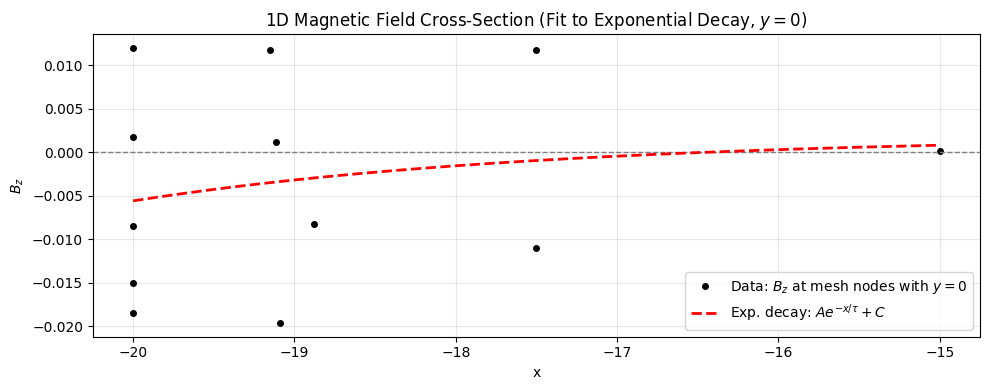

In [57]:
# 1D cross-section of magnetic field Bz using ONLY mesh nodes at y = 0
# Run this after the cell that computes A_sol and creates `vis`.
B_nodes = np.asarray(vis._project_bz_to_nodes(A_sol)).ravel()
x_p1, y_p1, _ = vis._p1_plot_triangulation()

# Floating-point-safe selection of nodes exactly on y = 0
tol = 2.5
mask = np.isclose(y_p1, 0.0, atol=tol)

if not np.any(mask):
    raise ValueError(
        "No mesh nodes found at y=0. "
        "Try refining mesh or use a small |y| cutoff for an approximate section."
    )

x_plot = np.asarray(x_p1[mask]).ravel()
bz_plot = np.asarray(B_nodes[mask]).ravel()

# Sort left-to-right for plotting
order = np.argsort(x_plot)
x_plot = x_plot[order]
bz_plot = bz_plot[order]

# Filter to only values where x in [-20, -12]
mask_range = (x_plot >= -20) & (x_plot <= -15)
x_plot = x_plot[mask_range]
bz_plot = bz_plot[mask_range]

from scipy.optimize import curve_fit

# Define exponential decay model: A * exp(-x/tau) + C
def exp_decay(x, A, tau, C):
    return A * np.exp(-x / tau) + C

# Plot data and fit exponential decay

# Initial guesses for parameters: amplitude, decay constant, offset
A0 = bz_plot.max() - bz_plot.min()
tau0 = (x_plot.max() - x_plot.min()) / 2
C0 = bz_plot.min()

try:
    popt, pcov = curve_fit(exp_decay, x_plot, bz_plot, p0=[A0, tau0, C0])
    A_opt, tau_opt, C_opt = popt
    print(f"Fit parameters: A = {A_opt:.3g}, tau = {tau_opt:.3g}, C = {C_opt:.3g}")
except RuntimeError as e:
    print("Fit did not converge:", e)
    popt = None

plt.figure(figsize=(10, 4))
# Plot the data
plt.plot(x_plot, bz_plot, "o", color="black", ms=4, lw=1.5, label=r"Data: $B_z$ at mesh nodes with $y=0$")
plt.axhline(0.0, color="gray", linestyle="--", lw=1)

# Plot the exponential decay fit, if available
if popt is not None:
    x_fit = np.linspace(x_plot.min(), x_plot.max(), 200)
    bz_fit = exp_decay(x_fit, *popt)
    plt.plot(x_fit, bz_fit, 'r--', lw=2, label=r"Exp. decay: $A e^{-x/\tau} + C$")

plt.xlabel("x")
plt.ylabel(r"$B_z$")
plt.title(r"1D Magnetic Field Cross-Section (Fit to Exponential Decay, $y=0$)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()